<a href="https://colab.research.google.com/github/felimaker/IBM-Data-Science-Capstone/blob/main/4_eda_visualizacion.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Notebook 4: EDA con Visualización
**Proyecto:** Predicción de aterrizaje de la primera etapa del Falcon 9

**Objetivo:** Explorar visualmente las relaciones entre variables (sitio de
lanzamiento, órbita, masa de payload, número de vuelo) y la variable objetivo
`Class`, para identificar patrones que ayuden a explicar el éxito del aterrizaje.

Repositorio de GitHub: **https://github.com/felimaker/IBM-Data-Science-Capstone**


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Cargamos el archivo directamente desde la URL de respaldo del curso
url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-DS0321EN-SkillsNetwork/datasets/dataset_part_2.csv"
df = pd.read_csv(url)

df.head()


,FlightNumber,Date,BoosterVersion,PayloadMass,Orbit,LaunchSite,Outcome,Flights,GridFins,Reused,Legs,LandingPad,Block,ReusedCount,Serial,Longitude,Latitude,Class
0,1,2010-06-04,Falcon 9,6104.959412,LEO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0003,-80.577366,28.561857,0
1,2,2012-05-22,Falcon 9,525.000000,LEO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0005,-80.577366,28.561857,0
2,3,2013-03-01,Falcon 9,677.000000,ISS,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0007,-80.577366,28.561857,0
3,4,2013-09-29,Falcon 9,500.000000,PO,VAFB SLC 4E,False Ocean,1,False,False,False,NaN,1.0,0,B1003,-120.610829,34.632093,0
4,5,2013-12-03,Falcon 9,3170.000000,GTO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B1004,-80.577366,28.561857,0


## Gráfico 1: Dispersión — FlightNumber vs LaunchSite
**Propósito:** ver si a medida que aumenta el número de vuelos (experiencia acumulada
de SpaceX), el sitio de lanzamiento influye en el éxito del aterrizaje.


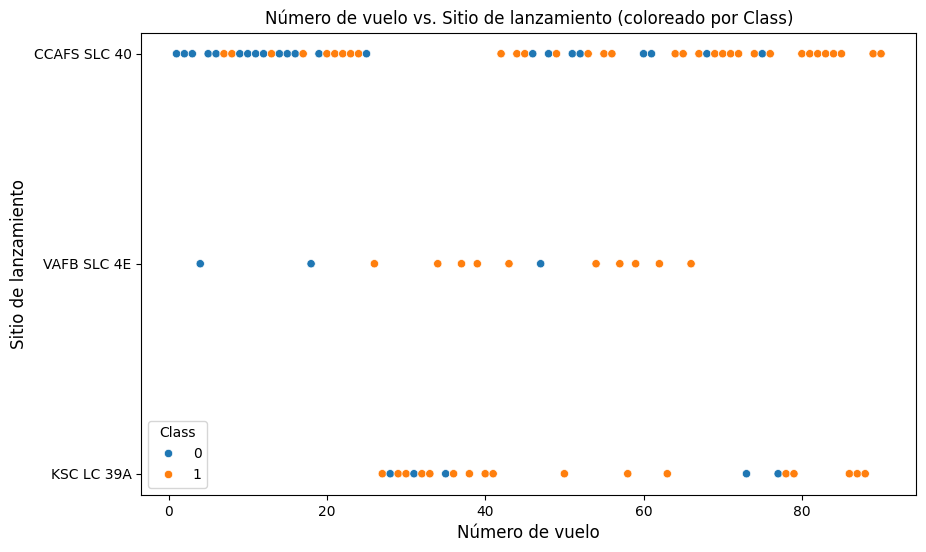

In [4]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='FlightNumber', y='LaunchSite', hue='Class')
plt.xlabel('Número de vuelo', fontsize=12)
plt.ylabel('Sitio de lanzamiento', fontsize=12)
plt.title('Número de vuelo vs. Sitio de lanzamiento (coloreado por Class)')
plt.savefig('scatter_flight_launchsite.png', dpi=150, bbox_inches='tight')
plt.show()


## Gráfico 2: Dispersión — PayloadMass vs LaunchSite
**Propósito:** evaluar si las cargas más pesadas se concentran en ciertos sitios y si
eso afecta la tasa de éxito.


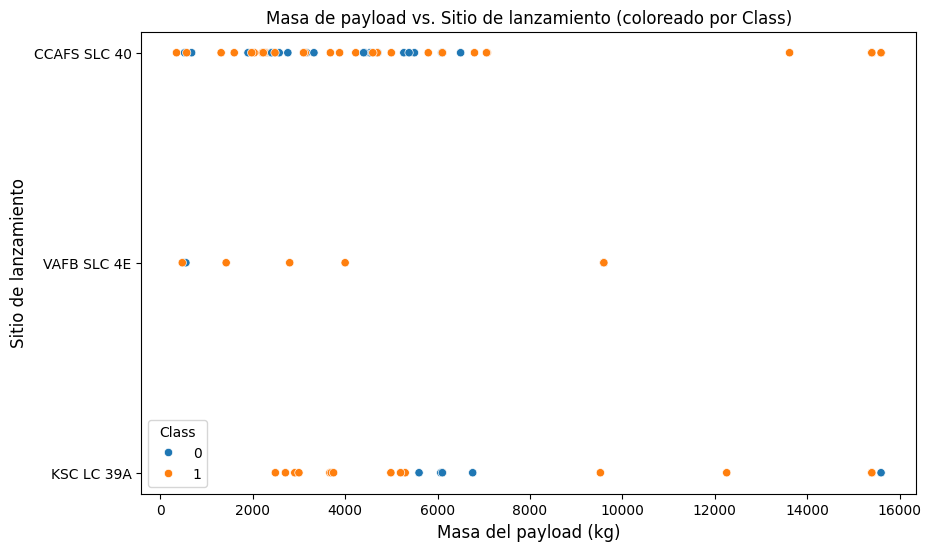

In [5]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='PayloadMass', y='LaunchSite', hue='Class')
plt.xlabel('Masa del payload (kg)', fontsize=12)
plt.ylabel('Sitio de lanzamiento', fontsize=12)
plt.title('Masa de payload vs. Sitio de lanzamiento (coloreado por Class)')
plt.savefig('scatter_flight_launchsite.png', dpi=150, bbox_inches='tight')
plt.show()


## Gráfico 3: Barras — Tasa de éxito por órbita
**Propósito:** identificar qué tipos de órbita (LEO, GTO, ISS, etc.) tienen mayor
tasa de éxito de aterrizaje.


/tmp/ipykernel_1056/2872928342.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=orbit_success.index, y=orbit_success.values, palette='viridis')


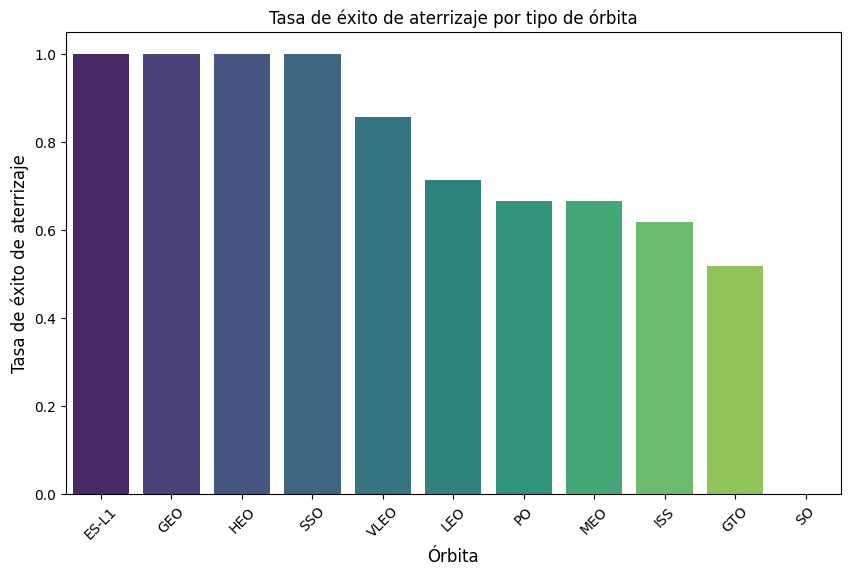

In [6]:
orbit_success = df.groupby('Orbit')['Class'].mean().sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=orbit_success.index, y=orbit_success.values, palette='viridis')
plt.xlabel('Órbita', fontsize=12)
plt.ylabel('Tasa de éxito de aterrizaje', fontsize=12)
plt.title('Tasa de éxito de aterrizaje por tipo de órbita')
plt.xticks(rotation=45)
plt.savefig('scatter_flight_launchsite.png', dpi=150, bbox_inches='tight')
plt.show()


## Gráfico 4: Dispersión — FlightNumber vs Orbit
**Propósito:** ver si, conforme avanza el número de vuelo, SpaceX empieza a lograr
más éxitos consistentes en órbitas específicas.


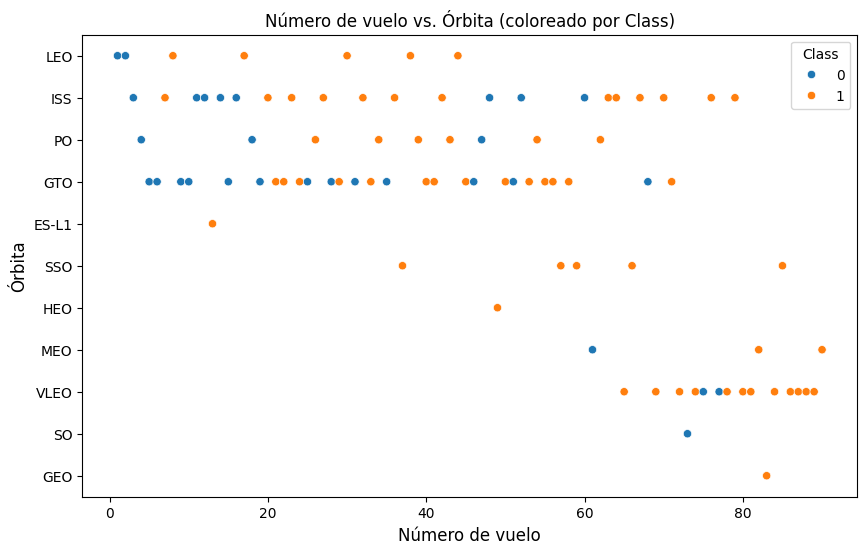

In [7]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='FlightNumber', y='Orbit', hue='Class')
plt.xlabel('Número de vuelo', fontsize=12)
plt.ylabel('Órbita', fontsize=12)
plt.title('Número de vuelo vs. Órbita (coloreado por Class)')
plt.savefig('scatter_flight_launchsite.png', dpi=150, bbox_inches='tight')
plt.show()


## Gráfico 5: Dispersión — PayloadMass vs Orbit
**Propósito:** analizar si ciertas combinaciones de masa/órbita (p. ej. cargas pesadas
a GTO) son sistemáticamente más difíciles de aterrizar.


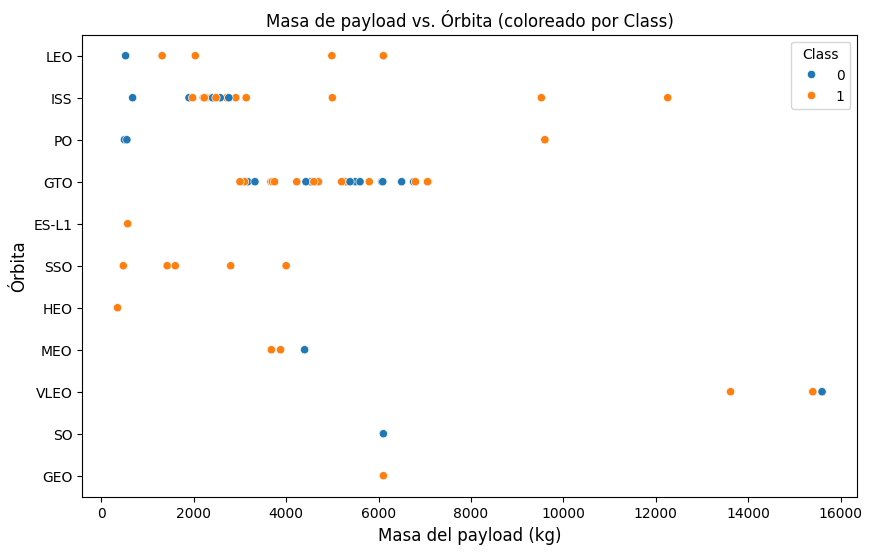

In [8]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='PayloadMass', y='Orbit', hue='Class')
plt.xlabel('Masa del payload (kg)', fontsize=12)
plt.ylabel('Órbita', fontsize=12)
plt.title('Masa de payload vs. Órbita (coloreado por Class)')
plt.savefig('scatter_flight_launchsite.png', dpi=150, bbox_inches='tight')
plt.show()


## Gráfico 6: Tendencia anual de la tasa de éxito
**Propósito:** mostrar la evolución de la tasa de éxito de aterrizaje año a año,
evidenciando la curva de aprendizaje de SpaceX.


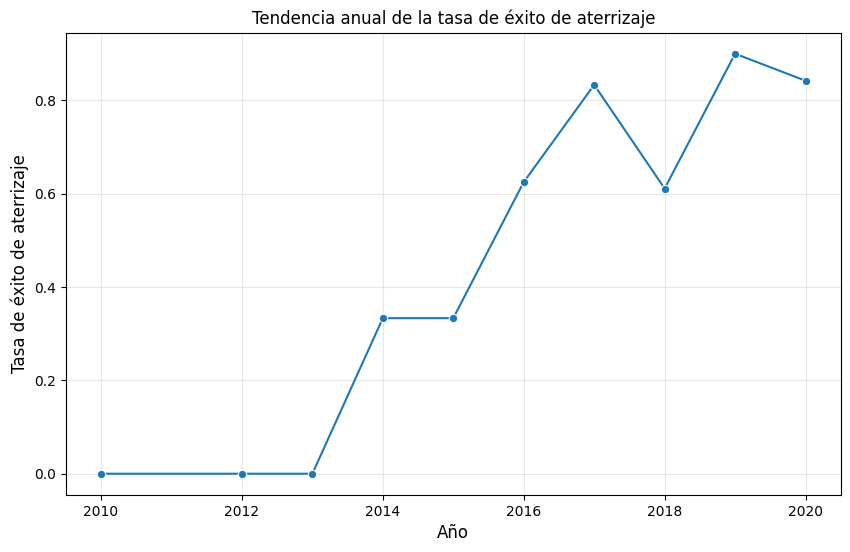

In [9]:
df['Date'] = pd.to_datetime(df['Date'])
df['Year'] = df['Date'].dt.year

yearly_success = df.groupby('Year')['Class'].mean()

plt.figure(figsize=(10, 6))
sns.lineplot(x=yearly_success.index, y=yearly_success.values, marker='o')
plt.xlabel('Año', fontsize=12)
plt.ylabel('Tasa de éxito de aterrizaje', fontsize=12)
plt.title('Tendencia anual de la tasa de éxito de aterrizaje')
plt.grid(True, alpha=0.3)
plt.savefig('scatter_flight_launchsite.png', dpi=150, bbox_inches='tight')
plt.show()


## Ingeniería de variables (features) para el modelado
Convertimos las variables categóricas relevantes en variables dummy (one-hot
encoding) para dejar el dataset listo para el modelado predictivo (Notebook 7).


In [11]:
features = df[['FlightNumber', 'PayloadMass', 'Orbit', 'LaunchSite', 'Flights',
               'GridFins', 'Reused', 'Legs', 'LandingPad', 'Block',
               'ReusedCount', 'Serial']]

features_one_hot = pd.get_dummies(
    features, columns=['Orbit', 'LaunchSite', 'LandingPad', 'Serial'])

features_one_hot = features_one_hot.astype('float64')
features_one_hot.to_csv('dataset_part_3.csv', index=False)
features_one_hot.head()


,FlightNumber,PayloadMass,Flights,GridFins,Reused,Legs,Block,ReusedCount,Orbit_ES-L1,Orbit_GEO,...,Serial_B1048,Serial_B1049,Serial_B1050,Serial_B1051,Serial_B1054,Serial_B1056,Serial_B1058,Serial_B1059,Serial_B1060,Serial_B1062
0,1.0,6104.959412,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2.0,525.000000,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,3.0,677.000000,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,4.0,500.000000,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,5.0,3170.000000,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## Resumen de la EDA con visualización
Se generaron 6 gráficos principales:
1. **FlightNumber vs LaunchSite** (dispersión) — evalúa aprendizaje por sitio.
2. **PayloadMass vs LaunchSite** (dispersión) — evalúa carga máxima manejable por sitio.
3. **Tasa de éxito por Orbit** (barras) — identifica las órbitas más "amigables" para
   el aterrizaje (ej. LEO, ISS) frente a las más difíciles (ej. GTO).
4. **FlightNumber vs Orbit** (dispersión) — curva de aprendizaje por tipo de órbita.
5. **PayloadMass vs Orbit** (dispersión) — combinación crítica masa/órbita.
6. **Tendencia anual de éxito** (línea) — muestra la mejora sostenida de SpaceX
   desde 2013 hasta 2020.

Además se generó el dataset con codificación *one-hot* de variables categóricas
(`dataset_part_3.csv`), insumo directo para el Notebook 7 de modelado predictivo.

Repositorio de GitHub: **https://github.com/felimaker/IBM-Data-Science-Capstone**
